In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1.Data collection

## I downloaded a ready-made dataset from Kaggle that meets the project requirements.

In [38]:
salary_dataSet = pd.read_csv("salary_synthetic.csv")

In [39]:
salary_dataSet

,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,36,Male,B.Sc,17.0,Junior,Enterprise,Tier-3,7.0,1.0,0,2.0,199330,84.0,2023-03-02,NaN
1996,30,Male,B.Sc,5.0,Mid,Startup,Remote,6.0,0.0,1,3.0,88626,53.0,2024-03-10,Built ML pipeline for preprocessing
1997,25,Female,B.Sc,0.0,Junior,Startup,Tier-1,1.0,1.0,0,0.0,32276,64.0,2023-12-05,Worked on microservices deployment
1998,29,Male,M.Sc,2.0,Senior,Enterprise,Remote,5.0,1.0,0,1.0,103449,49.0,2023-09-26,NaN


In [40]:
selected_columns = ['education', 'experience_years', 'certifications', 'salary_bdt']
salary_df = salary_dataSet[selected_columns]
salary_df

,education,experience_years,certifications,salary_bdt
0,M.Sc,6.0,2.0,145185
1,M.Sc,9.0,0.0,121262
2,B.Sc+Cert,NaN,1.0,184875
3,B.Sc,16.0,0.0,180105
4,B.Sc,8.0,2.0,114750
...,...,...,...,...
1995,B.Sc,17.0,1.0,199330
1996,B.Sc,5.0,0.0,88626
1997,B.Sc,0.0,1.0,32276
1998,M.Sc,2.0,1.0,103449


In [41]:
salary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   education         1900 non-null   str    
 1   experience_years  1840 non-null   float64
 2   certifications    1920 non-null   float64
 3   salary_bdt        2000 non-null   int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 62.6 KB


# 2. Data Cleaning

## 1. clean education column

In [42]:
clear_edu = salary_df.dropna(subset=['education'])
edu_salary_map = clear_edu.groupby('education')['salary_bdt'].median()
edu_salary_map

education
B.Sc         107487.5
B.Sc+Cert    109534.0
M.Eng        125789.0
M.Sc         121155.0
PhD          121909.0
Name: salary_bdt, dtype: float64

In [43]:
def edu_by_salary(salary):
    return (edu_salary_map - salary).abs().idxmin()

In [44]:
salary_df['education'] = salary_df.apply(
    lambda row : edu_by_salary(row['salary_bdt'])
    if pd.isna(row['education'])
    else row['education'],
    axis=1
)

## 2.clean certifications column

In [45]:
clear_certifications = salary_df.dropna(subset=['certifications'])
cer_salary_map = clear_certifications.groupby('certifications')['salary_bdt'].median()
cer_salary_map

certifications
0.0    110622.0
1.0    114373.5
2.0    110468.5
3.0    107935.0
4.0    111422.0
5.0    133853.5
7.0    128716.0
Name: salary_bdt, dtype: float64

In [46]:
def certifications_by_salary(salary):
    return (cer_salary_map - salary).abs().idxmin()

In [47]:
salary_df['certifications'] = salary_df.apply(
    lambda row : certifications_by_salary(row["salary_bdt"])
    if pd.isna(row['certifications'])
    else row['certifications'],
    axis=1
    )

## 3. clean experience_years column

In [48]:
exp_year_clear = salary_df.dropna(subset=['experience_years'])
exp_salary_map = salary_df.groupby('experience_years')['salary_bdt'].median()
exp_salary_map

experience_years
0.0      50466.5
1.0      57584.0
2.0      67251.0
3.0      72098.0
4.0      84781.5
5.0      88112.0
6.0      98705.5
7.0     108642.5
8.0     111714.5
9.0     123090.5
10.0    130629.0
11.0    142946.0
12.0    150363.0
13.0    155637.0
14.0    161631.0
15.0    171276.5
16.0    179782.0
17.0    189809.0
18.0    195882.5
19.0    199298.0
20.0    215558.0
21.0    228215.5
22.0    222321.0
23.0    242657.0
24.0    230033.0
25.0    296887.5
29.0    295552.0
Name: salary_bdt, dtype: float64

In [49]:
def exp_year_by_salary(salary):
    return (exp_salary_map - salary).abs().idxmin()

In [50]:
salary_df['experience_years'] = salary_df.apply(
    lambda row : exp_year_by_salary(row['salary_bdt'])
    if pd.isna(row['experience_years'])
    else row ['experience_years'],
    axis = 1
)

In [51]:
salary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   education         2000 non-null   str    
 1   experience_years  2000 non-null   float64
 2   certifications    2000 non-null   float64
 3   salary_bdt        2000 non-null   int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 62.6 KB


# Analysis of features' relationships with salary

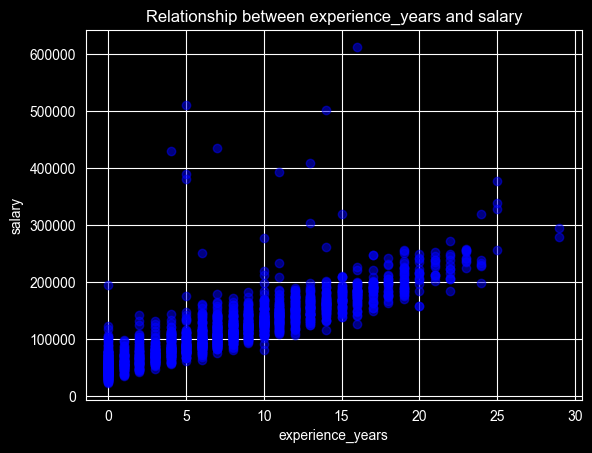

In [52]:
'''Relationship between experience_years and salary'''

plt.scatter(salary_df['experience_years'],salary_df['salary_bdt'],color='blue',alpha=0.5)
plt.xlabel('experience_years')
plt.ylabel('salary')
plt.title('Relationship between experience_years and salary')
plt.show()

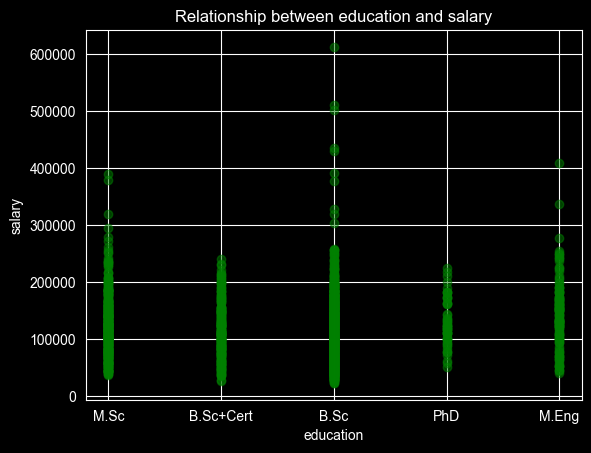

In [53]:
'''Relationship between education and salary'''

plt.scatter(salary_df['education'],salary_df['salary_bdt'],color='green',alpha=0.5)
plt.xlabel('education')
plt.ylabel('salary')
plt.title('Relationship between education and salary')
plt.show()

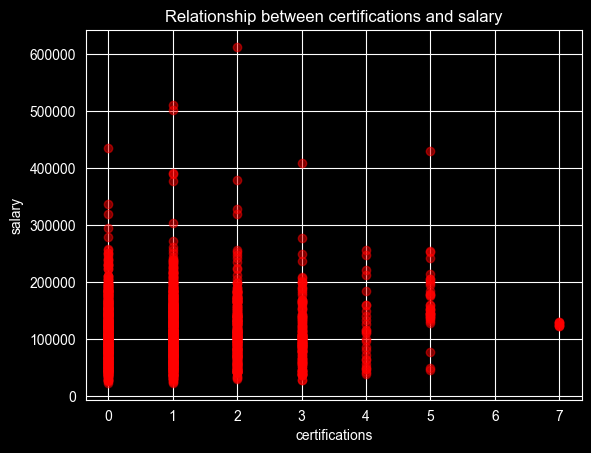

In [54]:
'''Relationship between certifications and salary'''

plt.scatter(salary_df['certifications'],salary_df['salary_bdt'],color='red',alpha=0.5)
plt.xlabel('certifications')
plt.ylabel('salary')
plt.title('Relationship between certifications and salary')
plt.show()

# 3.Preparing the data

In [55]:
numeric_features = ['certifications', 'experience_years']
categorical_features = ['education']
X = salary_df[numeric_features + categorical_features].copy()
Y = salary_df['salary_bdt'].copy()

In [56]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [57]:
preprocess = ColumnTransformer(
    transformers=[("cat",OneHotEncoder(drop='first'),categorical_features),
                  ("num","passthrough",numeric_features)]
)

# 4.Train the model

In [23]:
model = Pipeline(steps=[
    ('preprocess',preprocess),
    ('regressor', LinearRegression()),
])

model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

# 5.make prediction

In [24]:
Y_pred = model.predict(X_test)

In [25]:
print("Comparison of Actual vs Predicted Salary")
for actual, predicted in list(zip(Y_test[:10], Y_pred[:10])):
    print("Actual:", round(actual, 2), " | Predicted:", round(predicted, 2))

Comparison of Actual vs Predicted Salary
Actual: 137402  | Predicted: 106683.25
Actual: 92236  | Predicted: 103972.3
Actual: 261332  | Predicted: 173084.33
Actual: 97602  | Predicted: 98632.78
Actual: 37671  | Predicted: 55669.48
Actual: 61398  | Predicted: 71811.61
Actual: 88717  | Predicted: 87871.36
Actual: 57748  | Predicted: 58380.43
Actual: 185657  | Predicted: 179137.48
Actual: 109024  | Predicted: 133504.42


In [26]:
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("R2 :", r2_score(Y_test, Y_pred))

MSE: 969649103.1042137
R2 : 0.6924374163479798


# chart to show the difference between the actual and expected salary

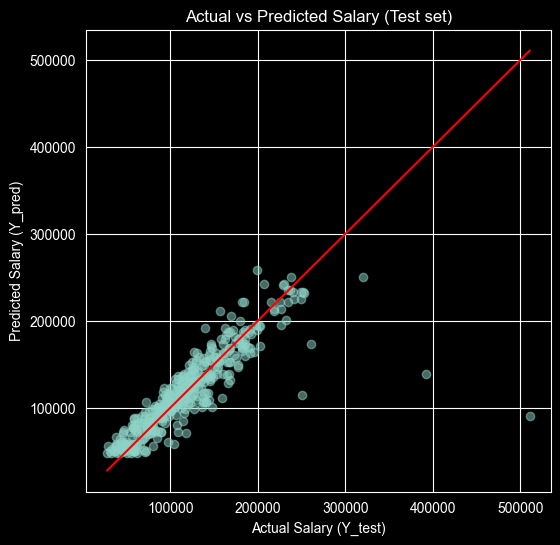

In [34]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, Y_pred, alpha=0.5)

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([max_val, min_val], [max_val, min_val],color ="red" , label='Ideal')

plt.xlabel("Actual Salary (Y_test)")
plt.ylabel("Predicted Salary (Y_pred)")
plt.title("Actual vs Predicted Salary (Test set)")
plt.show()